**load the final feature dataset and frozen split**

In [6]:
import pandas as pd
import numpy as np

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

split_df = pd.read_csv(
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

print(
    "Dataset:",
    df.shape
)

print(
    "Subjects:",
    df["subject_id"].nunique()
)

Dataset: (457577, 17)
Subjects: 197


**Recreate the normalized data**

In [7]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.normalization import (
    SleepFeatureScaler,
)

from src.preprocessing.sequences import (
    find_contiguous_runs,
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
)

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

df = pd.read_csv(FEATURES_PATH)

split_df = pd.read_csv(SPLIT_PATH)

df_with_split = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

train_df = (
    df_with_split[
        df_with_split["split"] == "train"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

val_df = (
    df_with_split[
        df_with_split["split"] == "val"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

test_df = (
    df_with_split[
        df_with_split["split"] == "test"
    ]
    .sort_values(
        ["subject_id", "start_time"]
    )
    .reset_index(drop=True)
)

feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    X_train_scaled.shape,
    X_val_scaled.shape,
    X_test_scaled.shape,
)

(319628, 10) (69602, 10) (68347, 10)


**Calculate sequence-target counts per subject**

In [8]:
from src.preprocessing.sequences import (
    find_contiguous_runs,
)

SEQUENCE_LENGTH = 10

stage_order = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

subject_sequence_counts = []

for subject_id, subject_df in (
    df.groupby("subject_id", sort=False)
):

    subject_df = (
        subject_df
        .sort_values("start_time")
        .reset_index(drop=True)
    )

    runs = find_contiguous_runs(
        subject_df
    )

    counts = {
        stage: 0
        for stage in stage_order
    }

    for run in runs:

        if len(run) < SEQUENCE_LENGTH:
            continue

        target_stages = (
            run["target_stage"]
            .iloc[
                SEQUENCE_LENGTH - 1:
            ]
        )

        counts.update({
            stage: counts[stage]
            + int(
                (target_stages == stage).sum()
            )
            for stage in stage_order
        })

    subject_sequence_counts.append(
        {
            "subject_id": subject_id,
            **counts,
        }
    )

subject_sequence_counts = pd.DataFrame(
    subject_sequence_counts
).set_index("subject_id")

print(
    "Subject sequence-target matrix:"
)

display(
    subject_sequence_counts.head(10)
)

Subject sequence-target matrix:


,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,1988,58,250,220,125
SC4002,1876,59,373,288,215
SC4011,1847,109,562,105,170
SC4012,1815,92,660,96,176
SC4021,1898,94,545,95,163
SC4022,1862,179,399,119,178
SC4031,1999,61,485,57,209
SC4032,1948,45,400,131,199
SC4041,1525,164,620,53,189


**Compare the current split using sequence targets**

In [9]:
current_sequence_split = (
    subject_sequence_counts
    .join( # type: ignore
        split_df.set_index(
            "subject_id"
        )
    )
)

sequence_split_counts = (
    current_sequence_split
    .groupby("split")[
        stage_order
    ]
    .sum()
)

sequence_split_percentages = (
    sequence_split_counts.div(
        sequence_split_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("Sequence target counts:")
display(
    sequence_split_counts
)

print(
    "\nSequence target percentages:"
)

display(
    sequence_split_percentages.round(2)
)

Sequence target counts:


,W,N1,N2,N3,REM
split,,,,,
test,43319,2946,13386,2858,5201
train,200350,18479,61809,12890,23472
val,44115,3417,12930,3672,5054



Sequence target percentages:


,W,N1,N2,N3,REM
split,,,,,
test,63.98,4.35,19.77,4.22,7.68
train,63.20,5.83,19.50,4.07,7.40
val,63.76,4.94,18.69,5.31,7.30


**Rebuild the sequences**

In [10]:
SEQUENCE_LENGTH = 10

X_train_seq, y_train_seq = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_val_seq, y_val_seq = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_test_seq, y_test_seq = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

print(
    "Training:",
    X_train_seq.shape,
)

print(
    "Validation:",
    X_val_seq.shape,
)

print(
    "Test:",
    X_test_seq.shape,
)

Training: (317000, 10, 10)
Validation: (69188, 10, 10)
Test: (67710, 10, 10)


**Check the corrected sequence distribution**

In [11]:
for split_name, targets in [
    ("Train", y_train_seq),
    ("Validation", y_val_seq),
    ("Test", y_test_seq),
]:

    counts = (
        pd.Series(targets)
        .value_counts()
        .reindex(
            [
                "W",
                "N1",
                "N2",
                "N3",
                "REM",
            ],
            fill_value=0,
        )
    )

    percentages = (
        counts
        / counts.sum()
        * 100
    )

    print(
        f"\n{split_name}"
    )

    print(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages.round(2),
        })
    )


Train
      count  percentage
W    200350       63.20
N1    18479        5.83
N2    61809       19.50
N3    12890        4.07
REM   23472        7.40

Validation
     count  percentage
W    44115       63.76
N1    3417        4.94
N2   12930       18.69
N3    3672        5.31
REM   5054        7.30

Test
     count  percentage
W    43319       63.98
N1    2946        4.35
N2   13386       19.77
N3    2858        4.22
REM   5201        7.68


**Verify which split contains SC4002**

In [12]:
sc4002_split = split_df.loc[
    split_df["subject_id"] == "SC4002",
    "split",
]

print(
    "SC4002 split:"
)

print(
    sc4002_split
)

SC4002 split:
1    val
Name: split, dtype: str


**Verify SC4002 sequence construction independently**

In [13]:
sc4002_df = (
    df[
        df["subject_id"] == "SC4002"
    ]
    .sort_values("start_time")
    .reset_index(drop=True)
)

sc4002_features_raw = (
    feature_scaler.transform(
        sc4002_df
    )
)

X_sc4002, y_sc4002 = (
    build_sequences_from_dataframe(
        dataframe=sc4002_df,
        feature_values=sc4002_features_raw,
        sequence_length=10,
    )
)

print(
    "SC4002 epochs:",
    len(sc4002_df),
)

print(
    "SC4002 sequences:",
    X_sc4002.shape,
)

print(
    "First SC4002 target:",
    y_sc4002[0],
)

print(
    "\nFirst 10 source epochs:"
)

display(
    sc4002_df[
        [
            "epoch_index",
            "start_time",
            "end_time",
            "target_stage",
        ]
    ].head(10)
)

SC4002 epochs: 2829
SC4002 sequences: (2811, 10, 10)
First SC4002 target: W

First 10 source epochs:


,epoch_index,start_time,end_time,target_stage
0,0,0.0,30.0,W
1,1,30.0,60.0,W
2,2,60.0,90.0,W
3,3,90.0,120.0,W
4,4,120.0,150.0,W
5,5,150.0,180.0,W
6,6,180.0,210.0,W
7,7,210.0,240.0,W
8,8,240.0,270.0,W
9,9,270.0,300.0,W


**Verify sequence counts from actual generated targets**

In [14]:
for split_name, targets in [
    ("Train", y_train_seq),
    ("Validation", y_val_seq),
    ("Test", y_test_seq),
]:

    counts = (
        pd.Series(targets)
        .value_counts()
        .reindex(
            [
                "W",
                "N1",
                "N2",
                "N3",
                "REM",
            ],
            fill_value=0,
        )
    )

    print(
        f"\n{split_name} total sequences:",
        len(targets),
    )

    print(counts)


Train total sequences: 317000
W      200350
N1      18479
N2      61809
N3      12890
REM     23472
Name: count, dtype: int64

Validation total sequences: 69188
W      44115
N1      3417
N2     12930
N3      3672
REM     5054
Name: count, dtype: int64

Test total sequences: 67710
W      43319
N1      2946
N2     13386
N3      2858
REM     5201
Name: count, dtype: int64


**Final training class weights**

In [15]:
from sklearn.utils.class_weight import compute_class_weight
from src.preprocessing.sequences import (
    CLASS_LABELS
)

class_indices = np.arange(5)

y_train = encode_sleep_stage_labels(
    y_train_seq
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=y_train,
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight
    in zip(
        class_indices,
        class_weights_array,
    )
}

print("Final baseline class weights:")

for class_index, weight in class_weights.items():
    print(
        f"{CLASS_LABELS[class_index]:>3} "
        f"(class {class_index}): "
        f"{weight:.4f}"
    )

Final baseline class weights:
  W (class 0): 0.3164
 N1 (class 1): 3.4309
 N2 (class 2): 1.0257
 N3 (class 3): 4.9185
REM (class 4): 2.7011


**Create TensorFlow datasets for the corrected sequences**

In [16]:
import tensorflow as tf

BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_seq,
            y_train,
        )
    )
    .shuffle(
        buffer_size=10000,
        seed=42,
        reshuffle_each_iteration=True,
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

y_val = encode_sleep_stage_labels(
    y_val_seq
)

y_test = encode_sleep_stage_labels(
    y_test_seq
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_val_seq,
            y_val,
        )
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_test_seq,
            y_test,
        )
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Corrected TensorFlow datasets created.")

Corrected TensorFlow datasets created.


**Build the corrected baseline LSTM**

In [17]:
from src.models.lstm import (
    build_baseline_lstm,
    compile_baseline_lstm,
)

model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

model = compile_baseline_lstm(
    model,
    learning_rate=1e-3,
)

model.summary()

Model: "baseline_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,525 (76.27 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 0 (0.00 B)

**Train corrected baseline LSTM**

In [18]:
from tensorflow import keras

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7667 - loss: 0.6946 - val_accuracy: 0.5849 - val_loss: 1.3576 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8046 - loss: 0.6051 - val_accuracy: 0.6441 - val_loss: 1.1389 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8148 - loss: 0.5721 - val_accuracy: 0.6169 - val_loss: 1.2245 - learning_rate: 0.0010
Epoch 4/30
1236/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8201 - loss: 0.5528
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8200 - loss: 0.5536 - val_accuracy: 0.6344 - val_loss: 1.1593 - learning_rate: 0.0010
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8190 - loss: 0.5543 - val_accuracy: 0.6507 - val_loss: 1.1330 - learning_rate: 5.0000e-04
Epoch 6/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.824

**Evaluate corrected baseline**

In [19]:
print("Validation:")
val_results = model.evaluate(
    val_dataset,
    verbose=1,
    return_dict=True,
)

print("\nTest:")
test_results = model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True,
)

print("\nValidation results:")
print(val_results)

print("\nTest results:")
print(test_results)

Validation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7856 - loss: 0.5649

Test:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8079 - loss: 0.5167

Validation results:
{'accuracy': 0.7856420278549194, 'loss': 0.5648670792579651}

Test results:
{'accuracy': 0.8078570365905762, 'loss': 0.516718864440918}


**Generate corrected test predictions**

In [20]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Corrected test classification report**

In [21]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9913    0.8783    0.9314     43319
          N1     0.2653    0.7016    0.3850      2946
          N2     0.7879    0.5996    0.6809     13386
          N3     0.6194    0.8537    0.7180      2858
         REM     0.5560    0.7925    0.6535      5201

    accuracy                         0.8079     67710
   macro avg     0.6440    0.7651    0.6738     67710
weighted avg     0.8704    0.8079    0.8277     67710



**Corrected baseline metrics**

In [22]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

accuracy = accuracy_score(
    y_test,
    y_test_pred,
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        y_test_pred,
    )
)

macro_precision = (
    precision_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

macro_recall = (
    recall_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

macro_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

weighted_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:          {accuracy:.4f}"
)

print(
    f"Balanced accuracy: {balanced_accuracy:.4f}"
)

print(
    f"Macro precision:   {macro_precision:.4f}"
)

print(
    f"Macro recall:      {macro_recall:.4f}"
)

print(
    f"Macro F1:          {macro_f1:.4f}"
)

print(
    f"Weighted F1:       {weighted_f1:.4f}"
)

Accuracy:          0.8079
Balanced accuracy: 0.7651
Macro precision:   0.6440
Macro recall:      0.7651
Macro F1:          0.6738
Weighted F1:       0.8277


**Corrected baseline confusion matrix**

Confusion matrix:
[[38045  2894  1365   394   621]
 [   96  2067   309    12   462]
 [  161  1923  8026  1091  2185]
 [   28    49   317  2440    24]
 [   48   859   170     2  4122]]


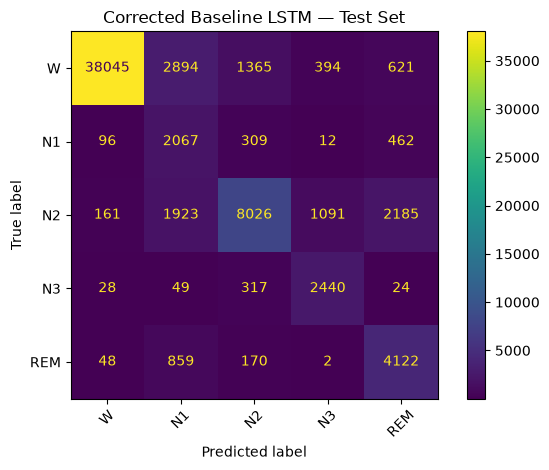

In [23]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_test_pred,
)

print("Confusion matrix:")
print(cm)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Corrected Baseline LSTM — Test Set"
)

plt.tight_layout()
plt.show()

**Save corrected weighted baseline**

In [24]:
BASELINE_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "baseline_lstm"
)

BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_MODEL_PATH = (
    BASELINE_DIR
    / "weighted_lstm.keras"
)

BASELINE_HISTORY_PATH = (
    BASELINE_DIR
    / "weighted_history.csv"
)

model.save(
    BASELINE_MODEL_PATH
)

pd.DataFrame(
    history.history
).to_csv(
    BASELINE_HISTORY_PATH,
    index=False,
)

print(
    "Model saved to:",
    BASELINE_MODEL_PATH,
)

print(
    "History saved to:",
    BASELINE_HISTORY_PATH,
)

Model saved to: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\weighted_lstm.keras
History saved to: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\weighted_history.csv


**Save weighted baseline metrics**

In [25]:
baseline_metrics = {
    "accuracy": accuracy,
    "balanced_accuracy": balanced_accuracy,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
}

baseline_metrics_df = pd.DataFrame(
    [baseline_metrics]
)

BASELINE_METRICS_PATH = (
    BASELINE_DIR
    / "weighted_metrics.csv"
)

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

print(
    "Metrics saved to:",
    BASELINE_METRICS_PATH,
)

Metrics saved to: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\weighted_metrics.csv


**Experiment 2 — Build unweighted LSTM**

In [26]:
from src.models.lstm import (
    build_baseline_lstm,
    compile_baseline_lstm,
)

unweighted_model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

unweighted_model = compile_baseline_lstm(
    unweighted_model,
    learning_rate=1e-3,
)

unweighted_model.summary()

Model: "baseline_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,525 (76.27 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 0 (0.00 B)

**Experiment 2 — Callbacks**

In [27]:
from tensorflow import keras

unweighted_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

**Experiment 2 — Train unweighted LSTM**

In [28]:
unweighted_history = unweighted_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=unweighted_callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8327 - loss: 0.4526 - val_accuracy: 0.6794 - val_loss: 0.8683 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8618 - loss: 0.3726 - val_accuracy: 0.7282 - val_loss: 0.7397 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8699 - loss: 0.3504 - val_accuracy: 0.7386 - val_loss: 0.7261 - learning_rate: 0.0010
Epoch 4/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8756 - loss: 0.3353 - val_accuracy: 0.7609 - val_loss: 0.6655 - learning_rate: 0.0010
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.8800 - loss: 0.3228 - val_accuracy: 0.7590 - val_loss: 0.6755 - learning_rate: 0.0010
Epoch 6/30
1238/1239 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8817 - loss: 0.3178
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8817 - 

**Experiment 2 — Evaluation**

In [29]:
print("Validation:")
unweighted_val_results = (
    unweighted_model.evaluate(
        val_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nTest:")
unweighted_test_results = (
    unweighted_model.evaluate(
        test_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nValidation results:")
print(unweighted_val_results)

print("\nTest results:")
print(unweighted_test_results)

Validation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8431 - loss: 0.4278

Test:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8509 - loss: 0.3987

Validation results:
{'accuracy': 0.8431086540222168, 'loss': 0.42778199911117554}

Test results:
{'accuracy': 0.8509082794189453, 'loss': 0.39867958426475525}


**Experiment 2 — Test predictions**

In [30]:
unweighted_test_probabilities = (
    unweighted_model.predict(
        test_dataset,
        verbose=1,
    )
)

unweighted_y_test_pred = np.argmax(
    unweighted_test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    unweighted_y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Experiment 2 — Classification report**

In [31]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test,
        unweighted_y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9570    0.9424    0.9496     43319
          N1     0.3886    0.3299    0.3569      2946
          N2     0.7339    0.7427    0.7383     13386
          N3     0.8061    0.6676    0.7303      2858
         REM     0.5982    0.7631    0.6707      5201

    accuracy                         0.8509     67710
   macro avg     0.6968    0.6892    0.6892     67710
weighted avg     0.8542    0.8509    0.8514     67710



**Experiment 2 — Evaluation metrics**

In [32]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

unweighted_accuracy = (
    accuracy_score(
        y_test,
        unweighted_y_test_pred,
    )
)

unweighted_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        unweighted_y_test_pred,
    )
)

unweighted_macro_precision = (
    precision_score(
        y_test,
        unweighted_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

unweighted_macro_recall = (
    recall_score(
        y_test,
        unweighted_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

unweighted_macro_f1 = (
    f1_score(
        y_test,
        unweighted_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

unweighted_weighted_f1 = (
    f1_score(
        y_test,
        unweighted_y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:          "
    f"{unweighted_accuracy:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{unweighted_balanced_accuracy:.4f}"
)

print(
    f"Macro precision:   "
    f"{unweighted_macro_precision:.4f}"
)

print(
    f"Macro recall:      "
    f"{unweighted_macro_recall:.4f}"
)

print(
    f"Macro F1:          "
    f"{unweighted_macro_f1:.4f}"
)

print(
    f"Weighted F1:       "
    f"{unweighted_weighted_f1:.4f}"
)

Accuracy:          0.8509
Balanced accuracy: 0.6892
Macro precision:   0.6968
Macro recall:      0.6892
Macro F1:          0.6892
Weighted F1:       0.8514


**Experiment 2 — Confusion matrix**

Confusion matrix:
[[40824   592  1568   104   231]
 [  780   972   676     2   516]
 [  643   553  9942   353  1895]
 [   57     4   865  1908    24]
 [  356   380   496     0  3969]]


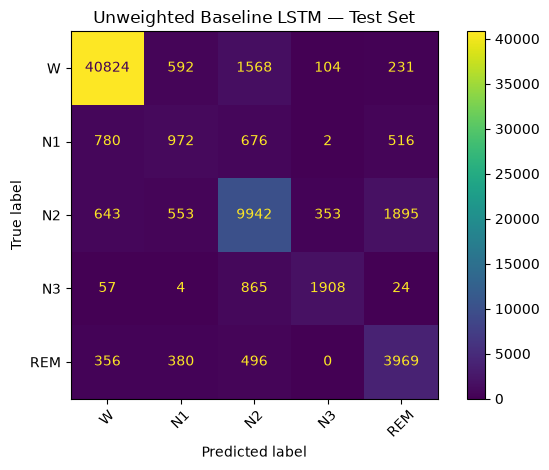

In [33]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

unweighted_cm = confusion_matrix(
    y_test,
    unweighted_y_test_pred,
)

print(
    "Confusion matrix:"
)

print(
    unweighted_cm
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=unweighted_cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Unweighted Baseline LSTM — Test Set"
)

plt.tight_layout()
plt.show()

**Compare Experiment 1 vs Experiment 2**

In [34]:
comparison = pd.DataFrame(
    {
        "Weighted": [
            accuracy,
            balanced_accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_f1,
        ],
        "Unweighted": [
            unweighted_accuracy,
            unweighted_balanced_accuracy,
            unweighted_macro_precision,
            unweighted_macro_recall,
            unweighted_macro_f1,
            unweighted_weighted_f1,
        ],
    },
    index=[
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
    ],
)

display(
    comparison.round(4)
)

,Weighted,Unweighted
Accuracy,0.8079,0.8509
Balanced Accuracy,0.7651,0.6892
Macro Precision,0.6440,0.6968
Macro Recall,0.7651,0.6892
Macro F1,0.6738,0.6892
Weighted F1,0.8277,0.8514


**Experiment 3 — Moderated class weights**

In [35]:
moderated_class_weights = {
    class_index: float(np.sqrt(weight))
    for class_index, weight
    in class_weights.items()
}

print("Moderated class weights:")

for class_index, weight in moderated_class_weights.items():
    print(
        f"{CLASS_LABELS[class_index]:>3} "
        f"(class {class_index}): "
        f"{weight:.4f}"
    )

Moderated class weights:
  W (class 0): 0.5625
 N1 (class 1): 1.8523
 N2 (class 2): 1.0128
 N3 (class 3): 2.2178
REM (class 4): 1.6435


**Experiment 3 — Build moderated-weight LSTM**

In [36]:
moderated_model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

moderated_model = compile_baseline_lstm(
    moderated_model,
    learning_rate=1e-3,
)

**Experiment 3 — Train with moderated class weights**

In [37]:
moderated_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

moderated_history = moderated_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=moderated_class_weights,
    callbacks=moderated_callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8177 - loss: 0.5401 - val_accuracy: 0.6343 - val_loss: 1.0137 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8449 - loss: 0.4651 - val_accuracy: 0.6542 - val_loss: 1.0008 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8540 - loss: 0.4378 - val_accuracy: 0.6936 - val_loss: 0.8677 - learning_rate: 0.0010
Epoch 4/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8599 - loss: 0.4219 - val_accuracy: 0.6809 - val_loss: 0.9364 - learning_rate: 0.0010
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8622 - loss: 0.4133 - val_accuracy: 0.7097 - val_loss: 0.8266 - learning_rate: 0.0010
Epoch 6/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8652 - loss: 0.4025 - val_accuracy: 0.6994 - val_loss: 0.8748 - learning_rate: 0.0010
Epoch 7/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8688 

**Experiment 3 — Evaluation**

In [38]:
print("Validation:")
moderated_val_results = (
    moderated_model.evaluate(
        val_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nTest:")
moderated_test_results = (
    moderated_model.evaluate(
        test_dataset,
        verbose=1,
        return_dict=True,
    )
)

print("\nValidation results:")
print(moderated_val_results)

print("\nTest results:")
print(moderated_test_results)

Validation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7740 - loss: 0.6461

Test:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7932 - loss: 0.5866

Validation results:
{'accuracy': 0.7739925980567932, 'loss': 0.6461496353149414}

Test results:
{'accuracy': 0.7932358384132385, 'loss': 0.5865805745124817}


**Experiment 3 — Test predictions**

In [39]:
moderated_test_probabilities = (
    moderated_model.predict(
        test_dataset,
        verbose=1,
    )
)

moderated_y_test_pred = np.argmax(
    moderated_test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    moderated_y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Experiment 3 — Classification report**

In [40]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

print(
    classification_report(
        y_test,
        moderated_y_test_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           W     0.9887    0.8549    0.9170     43319
          N1     0.3003    0.5876    0.3974      2946
          N2     0.6632    0.6777    0.6704     13386
          N3     0.6590    0.6837    0.6711      2858
         REM     0.4996    0.7535    0.6008      5201

    accuracy                         0.7932     67710
   macro avg     0.6222    0.7115    0.6513     67710
weighted avg     0.8429    0.7932    0.8110     67710



**Experiment 3 — Evaluation metrics**

In [41]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

moderated_accuracy = (
    accuracy_score(
        y_test,
        moderated_y_test_pred,
    )
)

moderated_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        moderated_y_test_pred,
    )
)

moderated_macro_precision = (
    precision_score(
        y_test,
        moderated_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

moderated_macro_recall = (
    recall_score(
        y_test,
        moderated_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

moderated_macro_f1 = (
    f1_score(
        y_test,
        moderated_y_test_pred,
        average="macro",
        zero_division=0,
    )
)

moderated_weighted_f1 = (
    f1_score(
        y_test,
        moderated_y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:          "
    f"{moderated_accuracy:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{moderated_balanced_accuracy:.4f}"
)

print(
    f"Macro precision:   "
    f"{moderated_macro_precision:.4f}"
)

print(
    f"Macro recall:      "
    f"{moderated_macro_recall:.4f}"
)

print(
    f"Macro F1:          "
    f"{moderated_macro_f1:.4f}"
)

print(
    f"Weighted F1:       "
    f"{moderated_weighted_f1:.4f}"
)

Accuracy:          0.7932
Balanced accuracy: 0.7115
Macro precision:   0.6222
Macro recall:      0.7115
Macro F1:          0.6513
Weighted F1:       0.8110


**Experiment 3 — Confusion matrix**

Confusion matrix:
[[37034  1699  3112   614   860]
 [  253  1731   405     5   552]
 [  113  1310  9072   391  2500]
 [   13    29   848  1954    14]
 [   43   996   242     1  3919]]


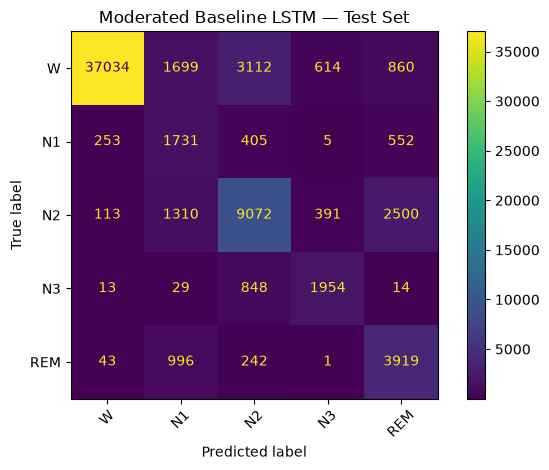

In [42]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

moderated_cm = confusion_matrix(
    y_test,
    moderated_y_test_pred,
)

print(
    "Confusion matrix:"
)

print(
    moderated_cm
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=moderated_cm,
    display_labels=class_names,
)

cm_display.plot(
    xticks_rotation=45,
)

plt.title(
    "Moderated Baseline LSTM — Test Set"
)

plt.tight_layout()
plt.show()

**Compare Experiment 1 vs Experiment 2 vs Experiment 3**

In [43]:
comparison = pd.DataFrame(
    {
        "Weighted": [
            accuracy,
            balanced_accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_f1,
        ],
        "Unweighted": [
            unweighted_accuracy,
            unweighted_balanced_accuracy,
            unweighted_macro_precision,
            unweighted_macro_recall,
            unweighted_macro_f1,
            unweighted_weighted_f1,
        ],
        "Moderated:": [
            moderated_accuracy,
            moderated_balanced_accuracy,
            moderated_macro_precision,
            moderated_macro_recall,
            moderated_macro_f1,
            moderated_weighted_f1,
        ]
    },
    index=[
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
    ],
)

display(
    comparison.round(4)
)

,Weighted,Unweighted,Moderated:
Accuracy,0.8079,0.8509,0.7932
Balanced Accuracy,0.7651,0.6892,0.7115
Macro Precision,0.6440,0.6968,0.6222
Macro Recall,0.7651,0.6892,0.7115
Macro F1,0.6738,0.6892,0.6513
Weighted F1,0.8277,0.8514,0.8110


**Save the official unweighted baseline**

In [44]:
BASELINE_DIR = (
    PROJECT_ROOT
    / "experiments"
    / "baseline_lstm"
)

BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_MODEL_PATH = (
    BASELINE_DIR
    / "unweighted_lstm.keras"
)

BASELINE_HISTORY_PATH = (
    BASELINE_DIR
    / "unweighted_history.csv"
)

BASELINE_METRICS_PATH = (
    BASELINE_DIR
    / "unweighted_metrics.csv"
)

unweighted_model.save(
    BASELINE_MODEL_PATH
)

pd.DataFrame(
    unweighted_history.history
).to_csv(
    BASELINE_HISTORY_PATH,
    index=False,
)

baseline_metrics = pd.DataFrame(
    [{
        "accuracy": unweighted_accuracy,
        "balanced_accuracy": (
            unweighted_balanced_accuracy
        ),
        "macro_precision": (
            unweighted_macro_precision
        ),
        "macro_recall": (
            unweighted_macro_recall
        ),
        "macro_f1": (
            unweighted_macro_f1
        ),
        "weighted_f1": (
            unweighted_weighted_f1
        ),
    }]
)

baseline_metrics.to_csv(
    BASELINE_METRICS_PATH,
    index=False,
)

print("Baseline model:")
print(BASELINE_MODEL_PATH)

print("\nBaseline history:")
print(BASELINE_HISTORY_PATH)

print("\nBaseline metrics:")
print(BASELINE_METRICS_PATH)

Baseline model:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\unweighted_lstm.keras

Baseline history:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\unweighted_history.csv

Baseline metrics:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm\unweighted_metrics.csv


**Reusable temporal-context experiment**

In [45]:
def train_temporal_model(
    X_train,
    y_train,
    X_val,
    y_val,
    sequence_length,
    experiment_name,
):
    """
    Train the same baseline LSTM architecture
    for a specified temporal context.
    """

    print(
        "=" * 70
    )
    print(
        f"Experiment: {experiment_name}"
    )
    print(
        f"Sequence length: "
        f"{sequence_length} epochs"
    )
    print(
        f"Temporal context: "
        f"{sequence_length * 30 / 60:.1f} minutes"
    )
    print(
        "=" * 70
    )

    model = build_baseline_lstm(
        sequence_length=sequence_length,
        n_features=10,
        n_classes=5,
        lstm_units=64,
        dropout_rate=0.30,
    )

    model = compile_baseline_lstm(
        model,
        learning_rate=1e-3,
    )

    batch_size = 256

    train_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_train,
                y_train,
            )
        )
        .shuffle(
            buffer_size=10000,
            seed=42,
            reshuffle_each_iteration=True,
        )
        .batch(batch_size)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    val_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_val,
                y_val,
            )
        )
        .batch(batch_size)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks,
        verbose=1,
    )

    return (
        model,
        history,
    )

**Build 5-epoch sequences**

In [46]:
X_train_5, y_train_5 = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=5,
    )
)

X_val_5, y_val_5 = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=5,
    )
)

X_test_5, y_test_5 = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=5,
    )
)

y_train_5 = encode_sleep_stage_labels(
    y_train_5
)

y_val_5 = encode_sleep_stage_labels(
    y_val_5
)

y_test_5 = encode_sleep_stage_labels(
    y_test_5
)

print(
    "5-epoch sequences:"
)

print(
    "Train:",
    X_train_5.shape
)

print(
    "Validation:",
    X_val_5.shape
)

print(
    "Test:",
    X_test_5.shape
)

5-epoch sequences:
Train: (318437, 5, 10)
Validation: (69418, 5, 10)
Test: (68062, 5, 10)


**Build 20-epoch sequences**

In [47]:
X_train_20, y_train_20 = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=20,
    )
)

X_val_20, y_val_20 = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=20,
    )
)

X_test_20, y_test_20 = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=20,
    )
)

y_train_20 = encode_sleep_stage_labels(
    y_train_20
)

y_val_20 = encode_sleep_stage_labels(
    y_val_20
)

y_test_20 = encode_sleep_stage_labels(
    y_test_20
)

print(
    "20-epoch sequences:"
)

print(
    "Train:",
    X_train_20.shape
)

print(
    "Validation:",
    X_val_20.shape
)

print(
    "Test:",
    X_test_20.shape
)

20-epoch sequences:
Train: (314291, 20, 10)
Validation: (68730, 20, 10)
Test: (67017, 20, 10)


**Experiment: 2.5-minute context**

In [48]:
model_5, history_5 = (
    train_temporal_model(
        X_train_5,
        y_train_5,
        X_val_5,
        y_val_5,
        sequence_length=5,
        experiment_name="LSTM_5_epochs",
    )
)

Experiment: LSTM_5_epochs
Sequence length: 5 epochs
Temporal context: 2.5 minutes
Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1244/1244 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8175 - loss: 0.4906 - val_accuracy: 0.6775 - val_loss: 0.8554 - learning_rate: 0.0010
Epoch 2/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8441 - loss: 0.4154 - val_accuracy: 0.6779 - val_loss: 0.8709 - learning_rate: 0.0010
Epoch 3/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8500 - loss: 0.4019 - val_accuracy: 0.6959 - val_loss: 0.8310 - learning_rate: 0.0010
Epoch 4/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8542 - loss: 0.3900 - val_accuracy: 0.6981 - val_loss: 0.8415 - learning_rate: 0.0010
Epoch 5/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8578 - loss: 0.3814 - val_accuracy: 0.7082 - val_loss: 0.8004 - learning_rate: 0.0010
Epoch 6/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8596 - loss: 0.3761 - val_accuracy: 0.7127 - val_loss: 0.8056 - learning_rate: 0.0010
Epoch 7/30
1244/1244 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8612 - loss

**Experiment: 10-minute context**

In [49]:
model_20, history_20 = (
    train_temporal_model(
        X_train_20,
        y_train_20,
        X_val_20,
        y_val_20,
        sequence_length=20,
        experiment_name="LSTM_20_epochs",
    )
)

Experiment: LSTM_20_epochs
Sequence length: 20 epochs
Temporal context: 10.0 minutes
Epoch 1/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.8424 - loss: 0.4270 - val_accuracy: 0.7515 - val_loss: 0.6735 - learning_rate: 0.0010
Epoch 2/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.8764 - loss: 0.3361 - val_accuracy: 0.7737 - val_loss: 0.6195 - learning_rate: 0.0010
Epoch 3/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.8853 - loss: 0.3107 - val_accuracy: 0.7785 - val_loss: 0.6201 - learning_rate: 0.0010
Epoch 4/30
1227/1228 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8901 - loss: 0.2962
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.8901 - loss: 0.2963 - val_accuracy: 0.7869 - val_loss: 0.6219 - learning_rate: 0.0010
Epoch 5/30
1228/1228 ━━━━━━━━━━━━━━━━━━━━ 29s 23ms/step - accuracy: 0.8911 - loss: 0.2926 - val_accuracy: 0.7963 - val_loss: 0.5818 - lea

**Evaluation helper**

In [50]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


def evaluate_model(
    model,
    X_test,
    y_test,
    model_name,
):
    test_ds = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                X_test,
                y_test,
            )
        )
        .batch(256)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )

    probabilities = model.predict(
        test_ds,
        verbose=1,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "balanced_accuracy": (
            balanced_accuracy_score(
                y_test,
                predictions,
            )
        ),
        "macro_precision": (
            precision_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_recall": (
            recall_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_f1": (
            f1_score(
                y_test,
                predictions,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": (
            f1_score(
                y_test,
                predictions,
                average="weighted",
                zero_division=0,
            )
        ),
    }

    print(
        f"\n{model_name}"
    )

    for key, value in metrics.items():
        if key != "model":
            print(
                f"{key}: {value:.4f}"
            )

    return (
        metrics,
        predictions,
    )

**Evaluate temporal-context models**

In [51]:
metrics_5, pred_5 = evaluate_model(
    model_5,
    X_test_5,
    y_test_5,
    "LSTM — 5 epochs",
)

metrics_20, pred_20 = evaluate_model(
    model_20,
    X_test_20,
    y_test_20,
    "LSTM — 20 epochs",
)

266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

LSTM — 5 epochs
accuracy: 0.8149
balanced_accuracy: 0.6625
macro_precision: 0.6517
macro_recall: 0.6625
macro_f1: 0.6485
weighted_f1: 0.8206
262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step

LSTM — 20 epochs
accuracy: 0.8668
balanced_accuracy: 0.6947
macro_precision: 0.7194
macro_recall: 0.6947
macro_f1: 0.7006
weighted_f1: 0.8667


**Compare temporal contexts**

In [52]:
temporal_results = pd.DataFrame(
    [
        metrics_5,
        {
            "model": "LSTM — 10 epochs",
            "accuracy": unweighted_accuracy,
            "balanced_accuracy": (
                unweighted_balanced_accuracy
            ),
            "macro_precision": (
                unweighted_macro_precision
            ),
            "macro_recall": (
                unweighted_macro_recall
            ),
            "macro_f1": (
                unweighted_macro_f1
            ),
            "weighted_f1": (
                unweighted_weighted_f1
            ),
        },
        metrics_20,
    ]
)

display(
    temporal_results.round(4)
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,LSTM — 5 epochs,0.8149,0.6625,0.6517,0.6625,0.6485,0.8206
1,LSTM — 10 epochs,0.8509,0.6892,0.6968,0.6892,0.6892,0.8514
2,LSTM — 20 epochs,0.8668,0.6947,0.7194,0.6947,0.7006,0.8667
